<a href="https://colab.research.google.com/github/balciberna/grokdataeda/blob/main/grok_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from os import path
import pandas as pd
file_path = '/content/gdrive/MyDrive/DataSet/grokcdata.csv'

df = pd.read_excel(file_path)
print ("Data is succesfully uploaded:")
display(df.head())

Data is succesfully uploaded:


,Cases,Date&Time,Tweet Fav,Tweet Quote,Tweet Reply,Tweet Retweet,Tweet View,Tweet Text,user_created_at,user_description,...,user_handle,user_is_blue_verified,user_location,user_media_count,tweet_mentions/0,tweet_mentions/1,tweet_mentions/2,is_grok_related,sentiment_score,ethical_score
0,Courtne14134948,Tue Jul 08 22:54:14 +0000 2025,3,0,0,0,21.0,@bennyjohnson @grok when does this go into eff...,Sun Jul 14 02:08:27 +0000 2024,NaN,...,Courtne14134948,False,Unknown,0,bennyjohnson,grok,NaN,True,0.994,0.5
1,Drew_sr88,Tue Jul 08 20:44:24 +0000 2025,2,0,1,0,30.0,@WatcherGuru @grok is the bullish or bearish f...,Wed Feb 10 23:07:25 +0000 2021,Proud Father,...,Drew_sr88,False,Unknown,0,WatcherGuru,grok,NaN,False,1.000,0.5
2,elevenchicago_,Tue Jul 08 22:58:49 +0000 2025,6,0,0,0,510.0,@FearedBuck @grok @grok stop ducking,Sat Feb 15 10:44:36 +0000 2025,unlock your potential | businesscreativity | ...,...,elevenchicago_,True,USA,0,FearedBuck,grok,grok,True,0.327,0.5
3,JiinxF67521,Tue Jul 08 23:00:31 +0000 2025,8,0,0,0,552.0,@grok @BasedNavonian @ChiefTrumpster WHAT,Wed Jan 17 13:49:41 +0000 2024,NaN,...,JiinxF67521,False,Unknown,0,grok,BasedNavonian,ChiefTrumpster,True,0.329,0.5
4,LEOLOX77,Tue Jul 08 21:30:14 +0000 2025,2,0,2,1,112.0,@DianeAxe @LauraLoomer @grok Is this above sta...,Sun Nov 24 02:47:26 +0000 2024,"Video Game Developer, over 200M+ plays on all ...",...,LEOLOX77,False,Unknown,0,DianeAxe,LauraLoomer,grok,True,0.199,0.5


In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# Turn Tweet texts into numeric vectors
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Tweet Text'])

# K-Means Cluster (3 Clusters: Grok, Pozitive, Negative)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Sonuçları analiz et
print(df.groupby('cluster')['sentiment_score'].mean())

cluster
0    0.473400
1    0.474357
2    0.482286
Name: sentiment_score, dtype: float64


In [ ]:
!pip install bertopic
from bertopic import BERTopic

# BERTopic modelini oluştur ve eğit
topic_model = BERTopic(language="english")
topics, probs = topic_model.fit_transform(df['Tweet Text'])

# Konuları görselleştir
topic_model.visualize_topics().show()

# Her konuyu incele
print(topic_model.get_topic_info())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.9 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

    Topic  Count                                               Name  \
0      -1   1347                                 -1_the_grok_and_to   
1       0    244                                  0_grok_is_it_they   
2       1    131                                    1_ai_and_to_the   
3       2    119               2_mechahitler_itself_calling_himself   
4       3     95                          3_stancil_will_rape_raped   
5       4     78                               4_elon_elons_to_woke   
6       5     75                            5_rn_grok_thanks_lmfaoo   
7       6     69                                6_mutuals_my_top_10   
8       7     65         7_grok_jimstewartson_pusholder_avaricum777   
9       8     60                        8_epstein_list_trump_client   
10      9     59  9_leonsghost14_francocarati_peddlingforpizz_ji...   
11     10     56                           10_nazi_full_reich_nazis   
12     11     45                        11_trump_tariff_under_20022   
13    

In [ ]:
from transformers import pipeline

# Hate speech detection modeli yükle (güncellenmiş model)
hate_speech_detector = pipeline("text-classification",
                                 model="cardiffnlp/twitter-roberta-base-hate")

# Analyse Tweets
results = hate_speech_detector(df['Tweet Text'].head(10).tolist())

for tweet, result in zip(df['Tweet Text'].head(10), results):
    print(f"Tweet: {tweet[:50]}...")
    print(f"Label: {result['label']}, Confidence: {result['score']:.3f}\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tweet: @bennyjohnson @grok when does this go into effect?...
Label: non-hate, Confidence: 0.973

Tweet: @WatcherGuru @grok is the bullish or bearish for c...
Label: non-hate, Confidence: 0.966

Tweet: @FearedBuck @grok @grok stop ducking...
Label: non-hate, Confidence: 0.909

Tweet: @grok @BasedNavonian @ChiefTrumpster WHAT...
Label: non-hate, Confidence: 0.961

Tweet: @DianeAxe @LauraLoomer @grok Is this above stateme...
Label: non-hate, Confidence: 0.971

Tweet: @ryangrim @grok AI is completely safe and containe...
Label: non-hate, Confidence: 0.964

Tweet: @elonmusk I can't believe you play these shitty Vi...
Label: non-hate, Confidence: 0.975

Tweet: @Rightanglenews @grok Analyze and describe in deta...
Label: non-hate, Confidence: 0.938

Tweet: @grok @PhilAmPatriot1 @Gritman303 @hodgetwins Grok...
Label: non-hate, Confidence: 0.978

Tweet: @unusual_whales @grok can you please describe how ...
Label: non-hate, Confidence: 0.979



In [ ]:
aggressive_keywords = ['hitler', 'antisemitic', 'fascist', 'traitor', 'whore', 'hate']

def contains_aggressive_content(text):
    return any(keyword in text.lower() for keyword in aggressive_keywords)

df['has_aggressive_content'] = df['Tweet Text'].apply(contains_aggressive_content)
print(f"Aggressive tweets: {df['has_aggressive_content'].sum()}")

Aggressive tweets: 350


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,      # En sık 1000 kelimeyi kullan
    ngram_range=(1, 2),     # Tek ve çift kelime kombinasyonları
    min_df=5,               # En az 5 dokümanda geçen kelimeler
    max_df=0.8              # En fazla %80 dokümanda geçen kelimeler
)

X = vectorizer.fit_transform(df['Tweet Text'])

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Compare Different Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(kernel='rbf'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10)
}

for name, model in models.items():
    scores = cross_val_score(model, X, df['is_grok_related'], cv=5)
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: 0.951 (+/- 0.001)
Random Forest: 0.951 (+/- 0.002)
SVM: 0.951 (+/- 0.001)
Decision Tree: 0.942 (+/- 0.004)


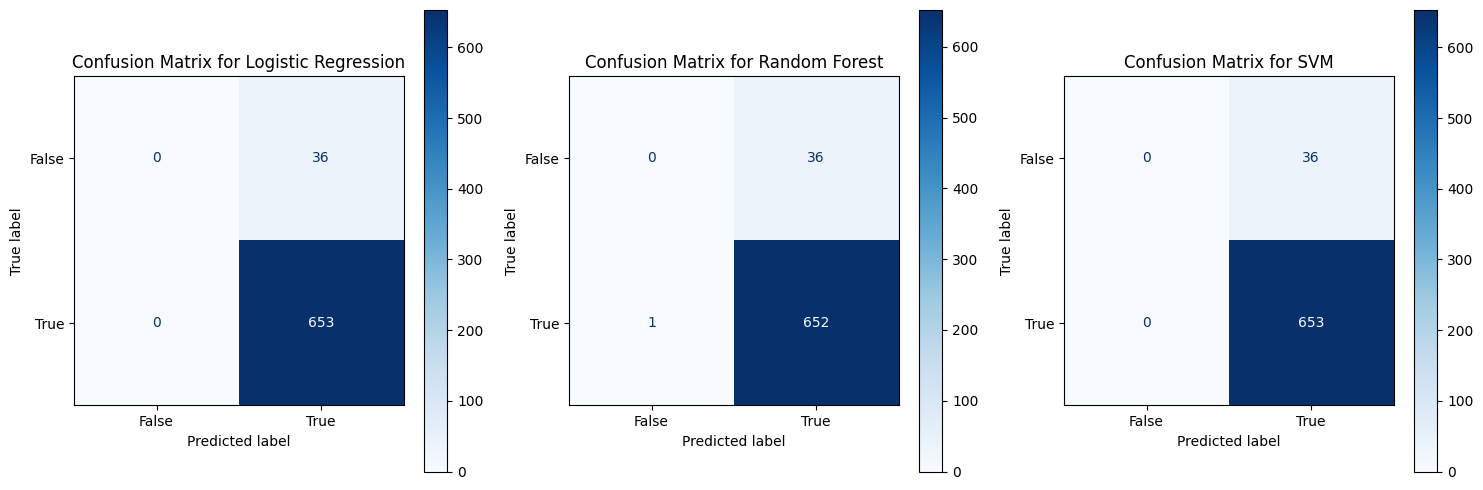

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Veriyi eğitim ve test kümelerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, df['is_grok_related'], test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), # Add solver for convergence
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True) # probability=True for consistent API with others if needed later
}

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    # Modeli eğitin
    model.fit(X_train, y_train)

    # Test seti üzerinde tahmin yapın
    y_pred = model.predict(X_test)

    # Karmaşıklık matrisini oluşturun
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    # Karmaşıklık matrisini görselleştirin
    ax = plt.subplot(1, 3, i + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix for {name}')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# En iyi modeli seç ve test et
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.3f}")

Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        36
        True       0.95      0.99      0.97       653

    accuracy                           0.94       689
   macro avg       0.47      0.50      0.49       689
weighted avg       0.90      0.94      0.92       689


Confusion Matrix:
[[  0  36]
 [  4 649]]

ROC-AUC Score: 0.514


In [ ]:
# Grok vs Non-Grok'un duygu skorlarını karşılaştır
grok_tweets = df[df['is_grok_related']]
non_grok_tweets = df[~df['is_grok_related']]

print(f"Grok Mean Sentiment: {grok_tweets['sentiment_score'].mean():.3f}")
print(f"Non-Grok Mean Sentiment: {non_grok_tweets['sentiment_score'].mean():.3f}")

# İstatistiksel test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(grok_tweets['sentiment_score'],
                             non_grok_tweets['sentiment_score'])
print(f"T-test p-value: {p_value:.4f}")

Grok Mean Sentiment: 0.475
Non-Grok Mean Sentiment: 0.523
T-test p-value: 0.0301


In [ ]:
# Random Forest'ın öğrendiği en önemli kelimeleri göster
feature_names = vectorizer.get_feature_names_out()
importances = best_model.feature_importances_

top_features = pd.DataFrame({
    'word': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

print(top_features)

               word  importance
173              co    0.015991
420        https co    0.015079
807             the    0.013368
419           https    0.012783
565     mechahitler    0.010610
154           calls    0.009811
453              is    0.009186
109              be    0.008846
853              to    0.008842
55              and    0.008208
609              no    0.007836
50   americawaffen_    0.007654
178          coming    0.007507
119         believe    0.007431
190          crypto    0.007428
151         calling    0.007324
201         deleted    0.006990
469              it    0.006956
44               am    0.006875
322             got    0.006746


In [ ]:
# Agresif içeriğin duygu skoruyla ilişkisi
print(df[df['has_aggressive_content']]['sentiment_score'].describe())
print(df[~df['has_aggressive_content']]['sentiment_score'].describe())

count    350.000000
mean       0.487106
std        0.289273
min        0.166000
25%        0.326000
50%        0.329000
75%        0.724500
max        1.000000
Name: sentiment_score, dtype: float64
count    3092.000000
mean        0.475940
std         0.280998
min         0.166000
25%         0.327000
50%         0.329000
75%         0.330000
max         1.000000
Name: sentiment_score, dtype: float64


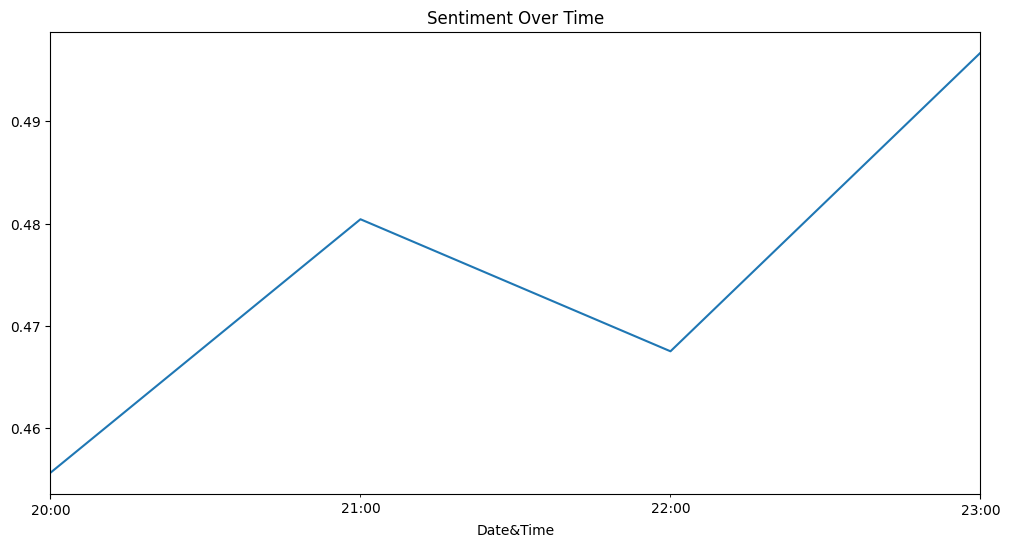

In [ ]:
# Grok'un davranışı zamanla nasıl değişti?
df['Date&Time'] = pd.to_datetime(df['Date&Time'])
df_sorted = df.sort_values('Date&Time')

# Saatlik ortalama duygu skoru
hourly_sentiment = df_sorted.set_index('Date&Time').resample('H')['sentiment_score'].mean()
hourly_sentiment.plot(figsize=(12, 6))
plt.title('Sentiment Over Time')
plt.show()

In [ ]:
# Hangi kelimeler Grok'u gösteriyor?
lr = LogisticRegression(random_state=42, solver='liblinear')
lr.fit(X_train, y_train)

feature_names = vectorizer.get_feature_names_out()
coefficients = lr.coef_[0]

# En pozitif (Grok'u gösterir)
top_grok_words = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False).head(20)

print("Top Grok indicators:")
print(top_grok_words)

Top Grok indicators:
             word  coefficient
990           you     0.818188
98             at     0.678882
965          with     0.656962
104         based     0.634438
23          after     0.591268
281       for the     0.586841
924            we     0.558276
589            my     0.548761
763       stancil     0.522104
649           own     0.513159
918           was     0.502739
837         think     0.502570
11          about     0.502387
961  will stancil     0.497564
891       twitter     0.487253
433            in     0.486534
602           new     0.473984
358     grok what     0.467409
245         every     0.453943
971          woke     0.447249
